In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Custom binned peptide counts saved to: /mnt/research/SERUGGIA/Internal/Paul_Batty/experiments/proteomics/exp0109_tmt_proteomics_tada1_dtag/csvs/combined_total_peptides_custom_binned_counts.csv


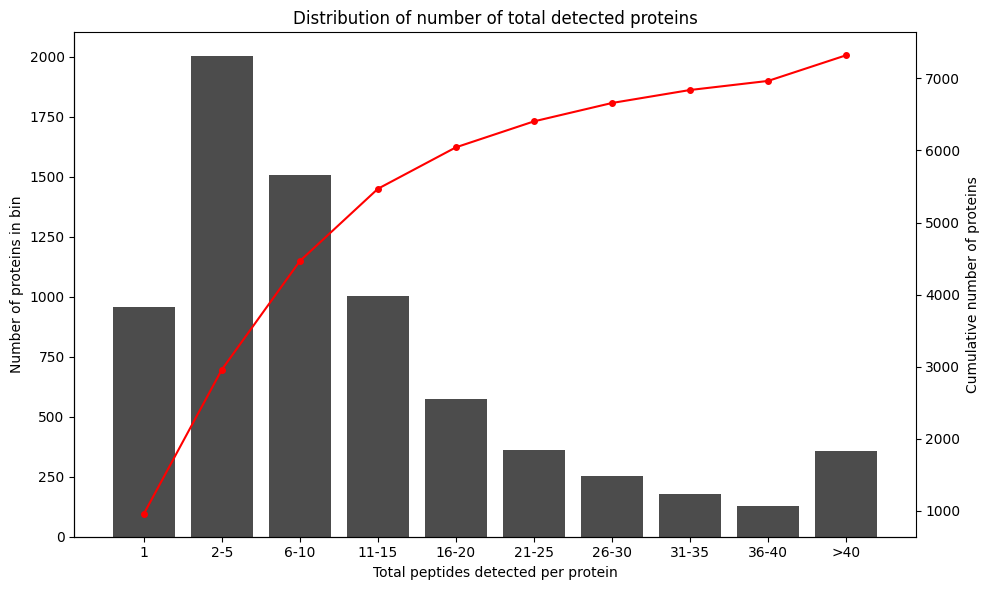

Histogram with cumulative curve (custom bins) saved to: /mnt/research/SERUGGIA/Internal/Paul_Batty/experiments/proteomics/exp0109_tmt_proteomics_tada1_dtag/plots/number_peptides_histogram/combined_total_peptides_histogram_cumulative_custom_bins.pdf


In [ ]:
#this script allows plotting of the number of peptides detected within specified bins as a histogram (custom bins).
#the cumulative number of proteins for which proteins are detected is plotted on the right y-axis.

input_dir = "/mnt/research/SERUGGIA/Internal/Paul_Batty/experiments/proteomics/exp0109_tmt_proteomics_tada1_dtag/data/250328_exp109_tmt_data/processed_data/MQ_100/Rescoring/"
base_output_dir = "/mnt/research/SERUGGIA/Internal/Paul_Batty/experiments/proteomics/exp0109_tmt_proteomics_tada1_dtag/"

input_file = "proteinGroups.fdr1.txt"

plot_dir = os.path.join(base_output_dir, "plots/number_peptides_histogram")
csv_dir = os.path.join(base_output_dir, "csvs")
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

# === LOAD DATA ===

input_path = os.path.join(input_dir, input_file)
df = pd.read_csv(input_path, sep="\t")

# === PROCESS 'Combined Total Peptides' COLUMN ===

# Drop NaN entries if any
peptide_counts = df['Combined Total Peptides'].dropna().astype(int)

# === DEFINE CUSTOM BINS ===

# Define function to assign bin label
def assign_bin(x):
    if x == 1:
        return '1'
    elif 2 <= x <= 5:
        return '2-5'
    elif 6 <= x <= 10:
        return '6-10'
    elif 11 <= x <= 15:
        return '11-15'
    elif 16 <= x <= 20:
        return '16-20'
    elif 21 <= x <= 25:
        return '21-25'
    elif 26 <= x <= 30:
        return '26-30'
    elif 31 <= x <= 35:
        return '31-35'
    elif 36 <= x <= 40:
        return '36-40'
    else:
        return '>40'
    

# Apply binning
peptide_bins = peptide_counts.apply(assign_bin)

# Count number of proteins in each bin
binned_counts = peptide_bins.value_counts().reindex(['1', '2-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36-40', '>40']).fillna(0)

# Calculate cumulative counts
cumulative_counts = binned_counts.cumsum()

# === SAVE Binned Counts CSV ===

binned_counts_df = pd.DataFrame({
    'Peptide Bin': binned_counts.index,
    'Number of Proteins': binned_counts.values,
    'Cumulative Number of Proteins': cumulative_counts.values
})

binned_csv_path = os.path.join(csv_dir, "combined_total_peptides_custom_binned_counts.csv")
binned_counts_df.to_csv(binned_csv_path, index=False)
print(f"Custom binned peptide counts saved to: {binned_csv_path}")

# === PLOT HISTOGRAM WITH CUMULATIVE CURVE ===

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar plot
ax1.bar(binned_counts.index, binned_counts.values, alpha=0.7, color='black')
ax1.set_xlabel('Total peptides detected per protein')
ax1.set_ylabel('Number of proteins in bin')
ax1.set_title('Distribution of number of total detected proteins')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xticks(range(len(binned_counts.index)))
ax1.set_xticklabels(binned_counts.index)

# Secondary axis for cumulative
ax2 = ax1.twinx()
ax2.plot(range(len(binned_counts.index)), cumulative_counts.values, color='red', marker='o', markersize=4)
ax2.set_ylabel('Cumulative number of proteins')
ax2.tick_params(axis='y')

plt.tight_layout()

# Save plot
plot_path = os.path.join(plot_dir, "combined_total_peptides_histogram_cumulative_custom_bins.pdf")
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"Histogram with cumulative curve (custom bins) saved to: {plot_path}")
